## Downstream analysis of AlphaFold2-Multimer output
#### This code is based on the code provided by the [VIB Tutorial](https://elearning.vib.be/courses/alphafold/)

In [1]:
import glob
import math
import os
import numpy as np
from matplotlib import pyplot as plt
import pickle
import pandas as pd
from pandas import json_normalize
import json

In [2]:
# select input directory
input_dir = "/Volumes/Intenso/alphafold/models/vub_multimer_gpr37l1_cdh9-ecd_model_20250819"

### Some statistics about the run times

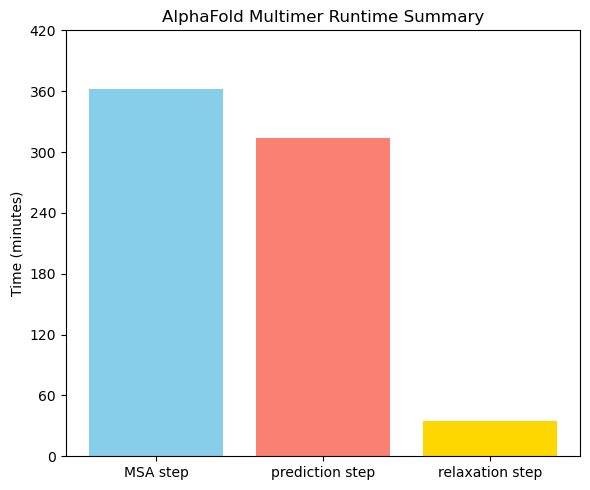

In [3]:
times_path = f"{input_dir}/timings.json"

with open(times_path) as f:
    times_data = json.load(f)


# run times of alphafold multimer
import matplotlib.pyplot as plt
from collections import defaultdict

# your timing data dict is called `data`

# Group timings
categories = defaultdict(float)
for k, v in times_data.items():
    if v < 1e-3:
        continue  # skip tiny times
    if k == "features":
        categories["MSA step"] += v
    elif "predict_and_compile" in k:
        categories["prediction step"] += v
    elif "relax" in k:
        categories["relaxation step"] += v

# Convert to minutes
categories_min = {k: v/60 for k, v in categories.items()}

# Plot
plt.figure(figsize=(6,5))
plt.bar(categories_min.keys(), categories_min.values(),
        color=["skyblue","salmon","gold"])
plt.ylabel("Time (minutes)")
plt.title("AlphaFold Multimer Runtime Summary")

max_val = max(categories_min.values())
plt.yticks(np.arange(0, max_val + 60, 60))

plt.tight_layout()
plt.show()

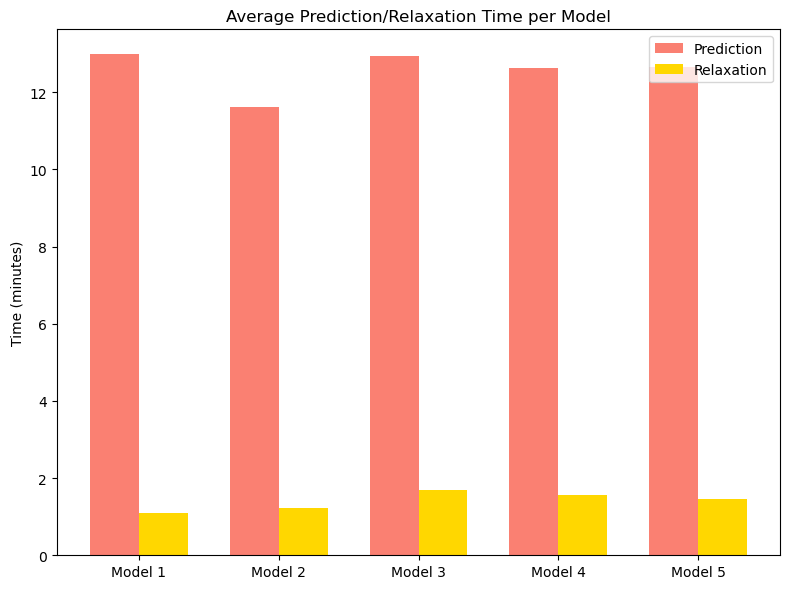

In [4]:
import re
import numpy as np

predict_times = defaultdict(list)
relax_times = defaultdict(list)

for k, v in times_data.items():
    if "predict_and_compile" in k:
        model = re.search(r"model_(\d+)", k).group(1)
        predict_times[model].append(v/60)
    elif "relax" in k:
        model = re.search(r"model_(\d+)", k).group(1)
        relax_times[model].append(v/60)

# Averages per model
model_avg = {}
for model in sorted(set(predict_times.keys()) | set(relax_times.keys()), key=int):
    model_avg[model] = {
        "predict_avg": np.mean(predict_times[model]),
        "relax_avg": np.mean(relax_times[model]),
    }

# Plot grouped bars
labels = list(model_avg.keys())
predict_vals = [model_avg[m]["predict_avg"] for m in labels]
relax_vals   = [model_avg[m]["relax_avg"] for m in labels]

x = np.arange(len(labels))
width = 0.35

plt.figure(figsize=(8,6))
plt.bar(x - width/2, predict_vals, width, label="Prediction", color="salmon")
plt.bar(x + width/2, relax_vals, width, label="Relaxation", color="gold")

plt.xticks(x, [f"Model {m}" for m in labels])
plt.ylabel("Time (minutes)")
plt.title("Average Prediction/Relaxation Time per Model")
plt.legend()
plt.tight_layout()
plt.show()

### AlphaFold Multimer scores and MSAs

In [5]:
# features and model names
feature_dict = pickle.load(open(f'{input_dir}/features.pkl','rb'))
model_names = sorted(glob.glob(f'{input_dir}/result_*.pkl'))

In [6]:
# function for extracting the pLDDT, PAE, PTM and iPTIM
def get_pae_plddt(model_names):
    out = {}
    for i,name in enumerate(model_names):
        d = pickle.load(open(name,'rb'))
        basename = os.path.basename(name)
        basename = basename[basename.index('model'):]
        out[f'{basename}'] = {
            "plddt": d["plddt"], ''
            "pae":d["predicted_aligned_error"], 
            "ptm":d["ptm"], 
            "iptm":d["iptm"]
        }
    return out

In [7]:
# apply the function
pae_plddt_per_model = get_pae_plddt(model_names)

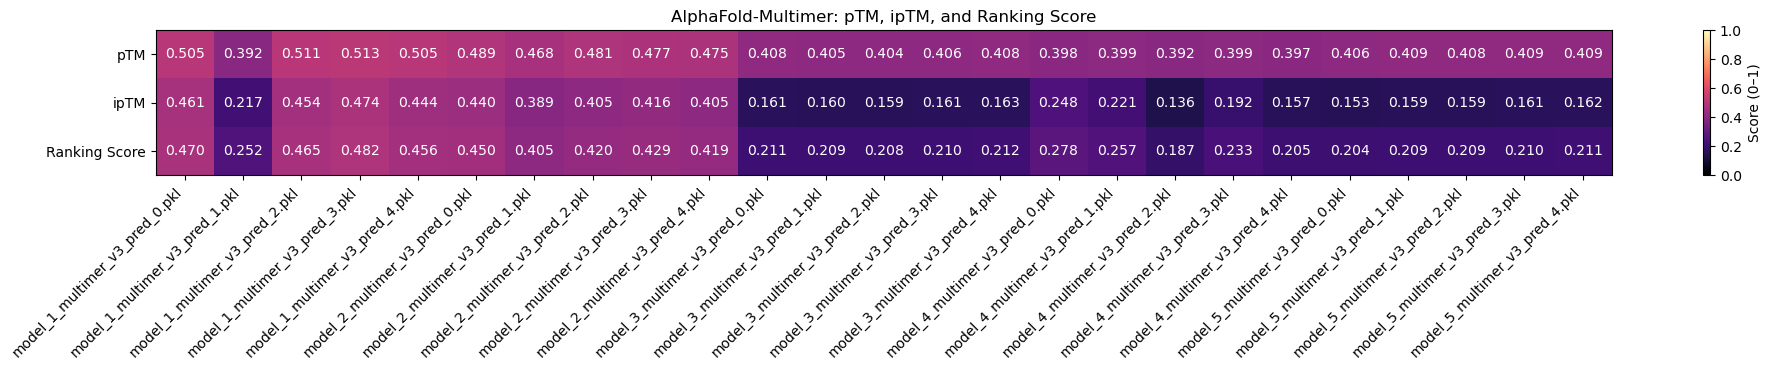

In [8]:
# plot the PTM, iPTM and combined ranking score
models = sorted(pae_plddt_per_model.keys())

ptm   = np.array([pae_plddt_per_model[m]["ptm"]  for m in models], dtype=float)
iptm  = np.array([pae_plddt_per_model[m]["iptm"] for m in models], dtype=float)
rank  = 0.8 * iptm + 0.2 * ptm

data = np.vstack([ptm, iptm, rank])

metric_labels = ["pTM", "ipTM", "Ranking Score"]

plt.figure(figsize=(max(8, 0.8*len(models)), 3.8))
im = plt.imshow(data, aspect="auto", interpolation="nearest", vmin=0, vmax=1, cmap="magma")
plt.colorbar(im, label="Score (0–1)")

plt.yticks(range(len(metric_labels)), metric_labels)
plt.xticks(range(len(models)), models, rotation=45, ha="right")

plt.title("AlphaFold-Multimer: pTM, ipTM, and Ranking Score")
plt.tight_layout()

for i in range(data.shape[0]):
    for j in range(data.shape[1]):
        plt.text(j, i, f"{data[i, j]:.3f}", ha="center", va="center", color="white")

plt.show()

In [9]:
# calculate the MSAs
msa = feature_dict['msa']
seqid = (np.array(msa[0] == msa).mean(-1))
seqid_sort = seqid.argsort()
non_gaps = (msa != 21).astype(float)
non_gaps[non_gaps == 0] = np.nan
final = non_gaps[seqid_sort] * seqid[seqid_sort, None]

Text(0, 0.5, 'Sequences')

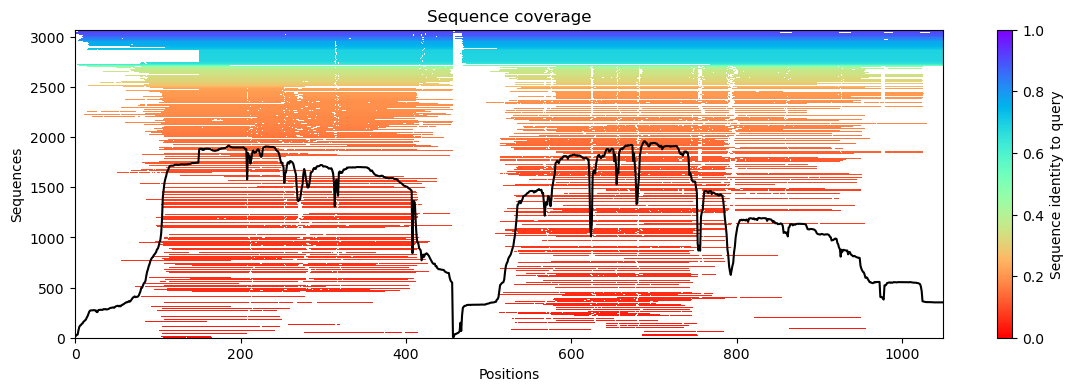

In [10]:
# plot the MSAs
plt.figure(figsize=(14, 4), dpi=100)
plt.title("Sequence coverage")
plt.imshow(final, interpolation='nearest', aspect='auto', cmap="rainbow_r", vmin=0, vmax=1, origin='lower')
plt.plot((msa != 21).sum(0), color='black')
plt.xlim(-0.5, msa.shape[1] - 0.5)
plt.ylim(-0.5, msa.shape[0] - 0.5)
plt.colorbar(label="Sequence identity to query", )
plt.xlabel("Positions")
plt.ylabel("Sequences")

Text(0.5, 0, 'Positions')

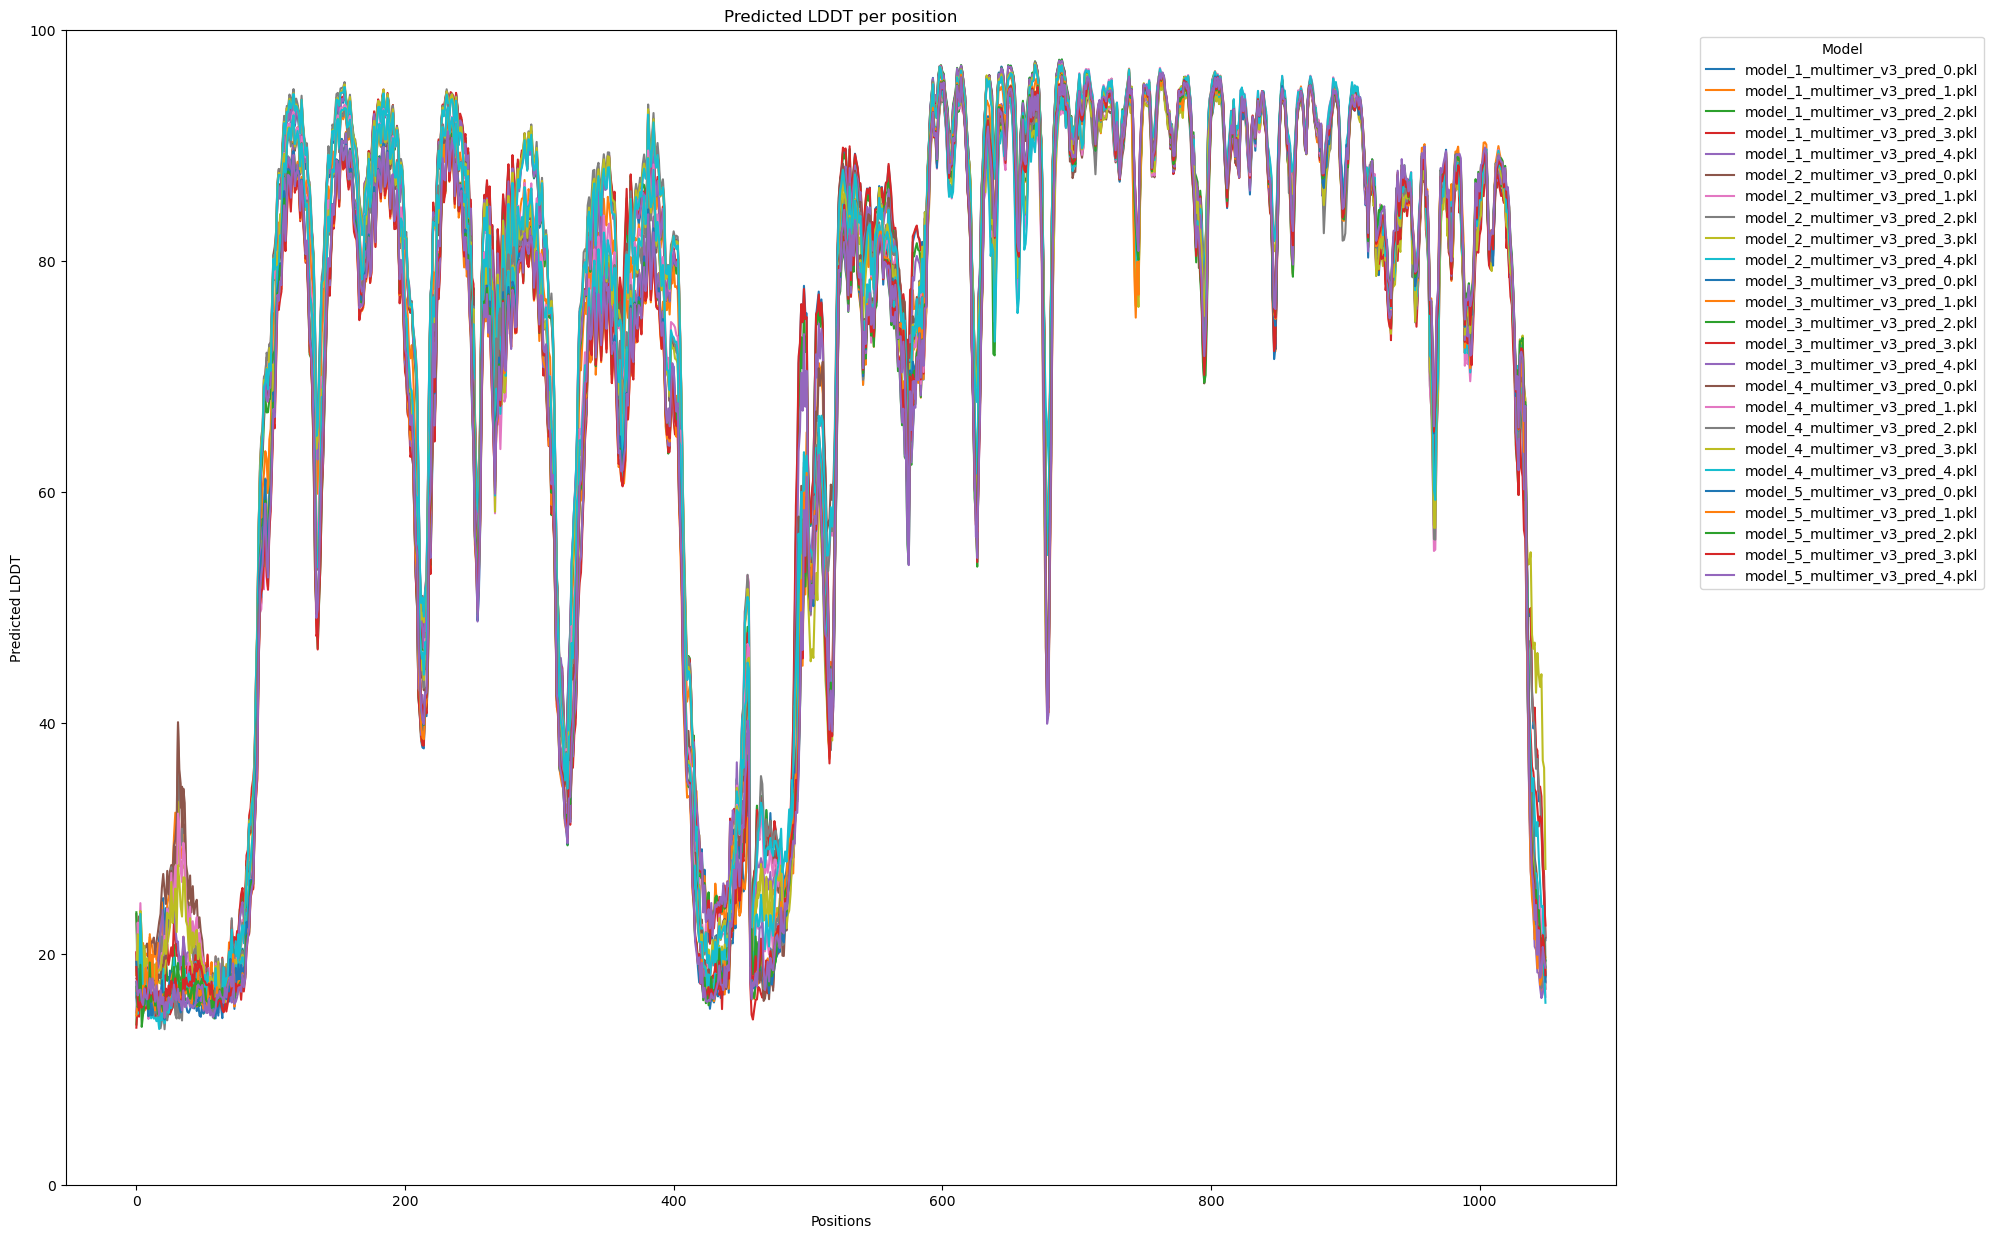

In [11]:
# Plot the pLLDTs
plt.figure(figsize=(20, 15)) 
plt.title("Predicted LDDT per position")
for model_name, value in pae_plddt_per_model.items():
    plt.plot(value["plddt"], label=model_name)
plt.ylim(0, 100)
plt.legend(title="Model", bbox_to_anchor=(1.05, 1), loc="upper left")

plt.ylabel("Predicted LDDT")
plt.xlabel("Positions")

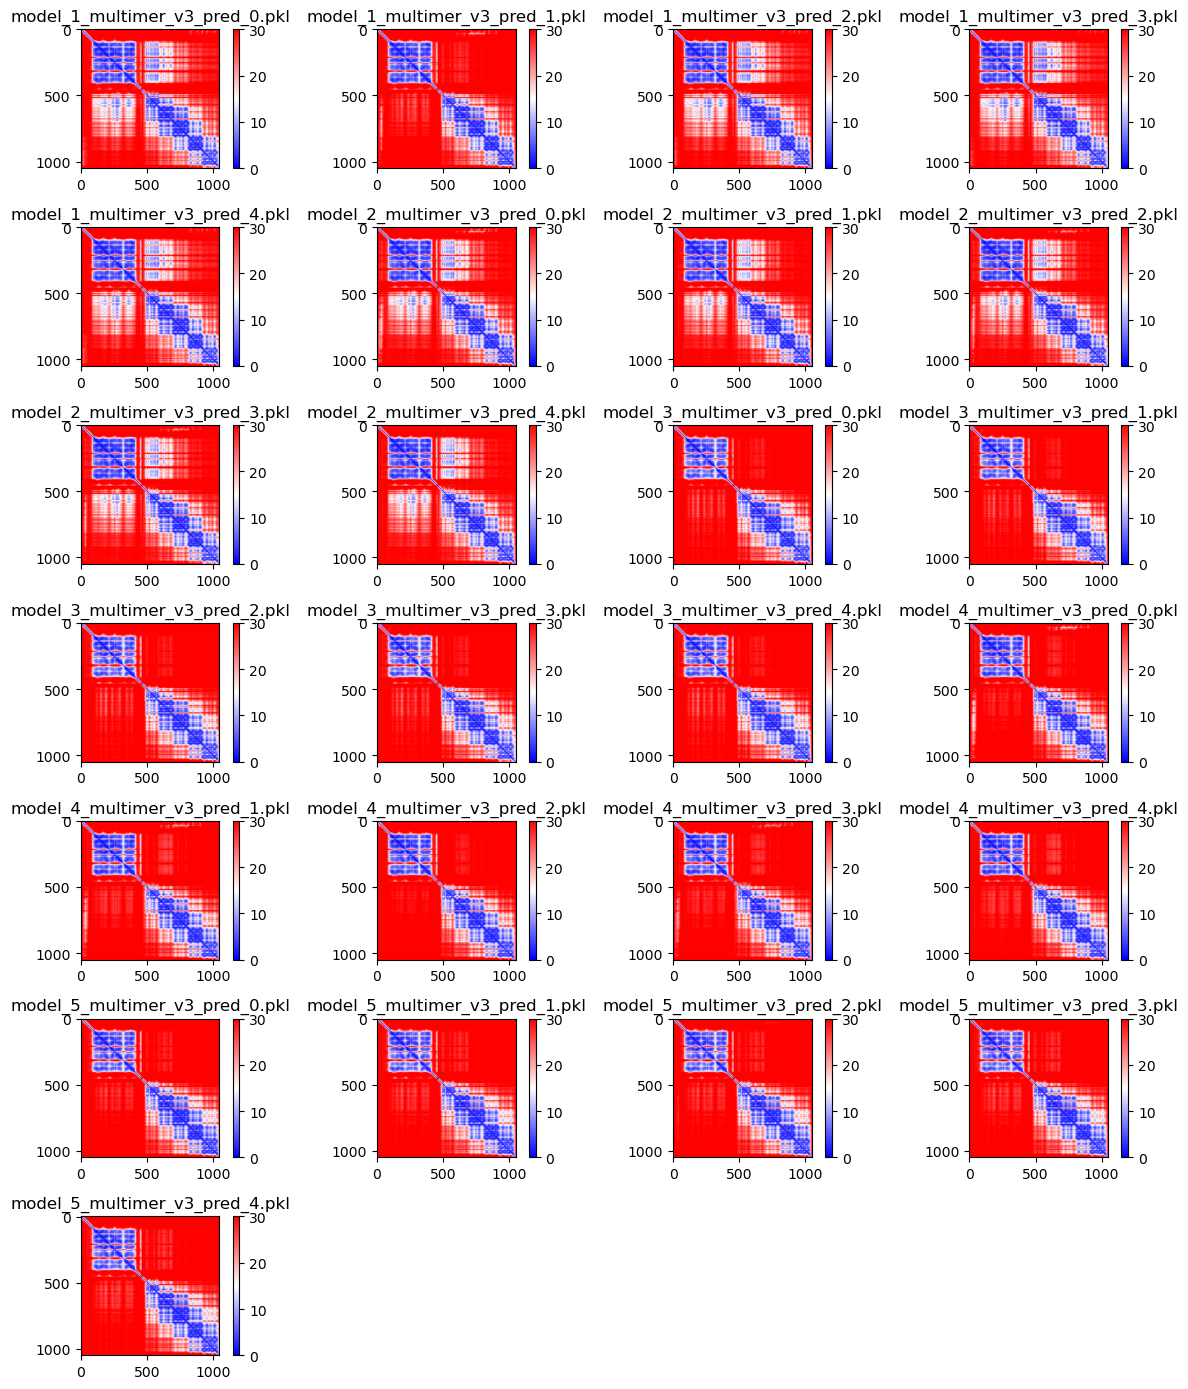

In [12]:
# plot the PAEs
num_models =4 # columns
num_runs_per_model = math.ceil(len(model_names)/num_models)
fig = plt.figure(figsize=(3 * num_models, 2 * num_runs_per_model), dpi=100)
for n, (model_name, value) in enumerate(pae_plddt_per_model.items()):
    plt.subplot(num_runs_per_model, num_models, n + 1)
    plt.title(model_name)
    plt.imshow(value["pae"], label=model_name, cmap="bwr", vmin=0, vmax=30)
    plt.colorbar()
fig.tight_layout()

### Code for making the Contact Map, Zoomed in Contact Map & the UniProt Topology Annotations bars next to it

In [13]:
import re
from pathlib import Path
from typing import Dict, List, Tuple
import numpy as np

import unicodedata
from biotite.database.uniprot import fetch
import biotite.structure as struc
import biotite.structure.io as strucio

import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.patches import Patch
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

In [20]:
# configurations for downstream contact map

af_path = Path(f"{input_dir}/ranked_0.pdb")

# protein A & B as in the raw AlphaFold file
protein_a_id = "A"        
protein_b_id = "B" 

# UniProt IDs for topology of the two proteins that you input in the alphafold pipeline
uidA = "Q99JG2" 
uidB = "P70407"

# threshold in angstroms that is considered a contact
contact_threshold = 8.0           

In [21]:
# getting the topology from UniProt Annotations using the library Biotite

Range = Tuple[int, int]

# helpers
def fetch_txt(uid: str) -> str:
    h = fetch(uid, format="txt") 
    return h.getvalue() if hasattr(h, "getvalue") else h.read()

def parse_length(txt: str) -> int:
    m = re.search(r"^SQ\s+SEQUENCE\s+(\d+)\s+AA;", txt, flags=re.M)
    if m:
        return int(m.group(1))
    ends = [int(x) for x in re.findall(r"(\d+)\.\.(\d+)", txt)]
    return max(ends) if ends else 0

def normalize_note(note: str) -> str:
    if note is None:
        return ""
    s = unicodedata.normalize("NFKC", str(note))
    s = s.replace('"', '').replace("'", "")
    s = re.sub(r"\s+", " ", s).strip().lower()
    return s

def classify_topo(note_norm: str):
    if re.search(r"\b(extracellular|extracytoplasmic|luminal|lumenal|lumen|periplasm(ic)?)\b", note_norm):
        return "Extracellular"
    if re.search(r"\b(cytoplasmic|cytoplasm|cytosolic|cytosol|intracellular|cytoplasmic side)\b", note_norm):
        return "Cytoplasmic"
    return None

def parse_features_from_txt(txt: str):
    """Return a list of {'ftype','loc','note'} for TOPO_DOM/TRANSMEM/SIGNAL features."""
    feats = []
    current = None
    for line in txt.splitlines():
        if not line.startswith("FT"):
            continue
        content = line[5:].rstrip()  
        if not content:
            continue

        m = re.match(r'(TOPO_DOM|TRANSMEM|SIGNAL)\s+(\d+\.\.\d+)', content)
        if m:
            current = {"ftype": m.group(1), "loc": m.group(2), "note": None}
            feats.append(current)
            continue

        if "/note=" in content and current:
            m = re.search(r'/note="([^"]+)"', content)
            if m:
                current["note"] = m.group(1)
    return feats

def parse_pos(loc: str) -> Range:
    m = re.match(r'(\d+)\.\.(\d+)', loc)
    if not m:
        raise ValueError(f"Unrecognized location: {loc}")
    return int(m.group(1)), int(m.group(2))

# the main function
def topology_labels(uid: str, treat_signal_as_extracellular: bool = True):
    txt = fetch_txt(uid)
    L = parse_length(txt)

    cats: Dict[str, List[Range]] = {
        "Extracellular": [], "Cytoplasmic": [], "Transmembrane": [], "Signal": []
    }

    last_side = None 

    for f in parse_features_from_txt(txt):
        start, end = parse_pos(f["loc"])
        ftype, note = f["ftype"], f["note"]

        if ftype == "TRANSMEM":
            cats["Transmembrane"].append((start, end))
            if last_side in ("Extracellular", "Cytoplasmic"):
                last_side = "Cytoplasmic" if last_side == "Extracellular" else "Extracellular"
            continue

        if ftype == "SIGNAL":
            cats["Signal"].append((start, end))
            last_side = "Extracellular"
            continue

        # TOPO_DOM
        side = classify_topo(normalize_note(note))
        if side is None:
            if last_side in ("Extracellular", "Cytoplasmic"):
                side = last_side
        if side is not None:
            cats[side].append((start, end))
            last_side = side 

    # AA level annotations
    labels = np.array(["Unknown"] * (L + 1), dtype=object)
    for a, b in cats["Extracellular"]:
        labels[a:b+1] = "Extracellular"
    for a, b in cats["Cytoplasmic"]:
        labels[a:b+1] = "Cytoplasmic"
    if treat_signal_as_extracellular:
        for a, b in cats["Signal"]:
            labels[a:b+1] = "Extracellular"
    else:
        for a, b in cats["Signal"]:
            labels[a:b+1] = "Signal"
    for a, b in cats["Transmembrane"]:
        labels[a:b+1] = "Transmembrane"

    return labels, {k: v for k, v in cats.items() if k != "Signal"}, L


In [22]:
# test example
uid = "Q99JG2" 
labels, ranges_by_cat, L = topology_labels(uid)
print(f"Sequence length: {L} AA")
for name, rr in ranges_by_cat.items():
    print(f"{name:14s}: " + (", ".join(f"{a}..{b}" for a, b in rr) if rr else "—"))

Sequence length: 481 AA
Extracellular : 25..134, 189..205, 273..310, 382..398
Cytoplasmic   : 156..167, 227..251, 332..360, 420..481
Transmembrane : 135..155, 168..188, 206..226, 252..272, 311..331, 361..381, 399..419


In [23]:
# loading the alphafold model and calculating the contacts
arr = strucio.load_structure(str(af_path))
arr = arr[struc.filter_amino_acids(arr)] # only AA residues
ca = arr[arr.atom_name == "CA"] # only carbon atoms to approximate residue positions

A = ca[ca.chain_id == protein_a_id]
B = ca[ca.chain_id == protein_b_id]
A = A[np.argsort(A.res_id)]
B = B[np.argsort(B.res_id)]

if len(A) == 0 or len(B) == 0:
    raise ValueError("Selected chains have no CA atoms. Check chain IDs (e.g., 'A', 'B').")

# calculating contacts between the two proteins
dists = np.linalg.norm(A.coord[:, None, :] - B.coord[None, :, :], axis=2).T 
contacts = dists <= contact_threshold


In [24]:
# mapping the topology labels to the AAs (for plotting)
labelsA, _, _ = topology_labels(uidA, treat_signal_as_extracellular=False)
labelsB, _, _ = topology_labels(uidB, treat_signal_as_extracellular=False)
offsetA = np.sum(labelsA == "Signal")
offsetB = np.sum(labelsB == "Signal")

def index_labels(vec, res_ids, offset=0):
    out = []
    for r in res_ids:
        i = r + offset 
        if 0 < i < len(vec):
            out.append(vec[i])
        else:
            raise IndexError(f"Residue {r} is out of bounds for label vector of length {len(vec)}, mapping of the topology annotations to the AA residues")
    return out

# index the labels using the offset
col_labels = index_labels(labelsA, A.res_id, offsetA)  # X-axis (chain A)
row_labels = index_labels(labelsB, B.res_id, offsetB)  # Y-axis (chain B)

color_map = {
    "Extracellular": "#8ed3c8",  
    "Cytoplasmic":   "#f38c61",   
    "Transmembrane": "#b3b3b3"
}

cats = list(color_map.keys())
cat_to_int = {c: i for i, c in enumerate(cats)}
cmap_topo = ListedColormap([color_map[c] for c in cats])
norm_topo = BoundaryNorm(np.arange(len(cats)+1)-0.5, len(cats))

col_codes = np.array([cat_to_int[x] for x in col_labels])
row_codes = np.array([cat_to_int[x] for x in row_labels])

/var/folders/q5/pgtbl_8x25ngl_1yyvg49y280000gn/T/ipykernel_23956/1419252589.py:47: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


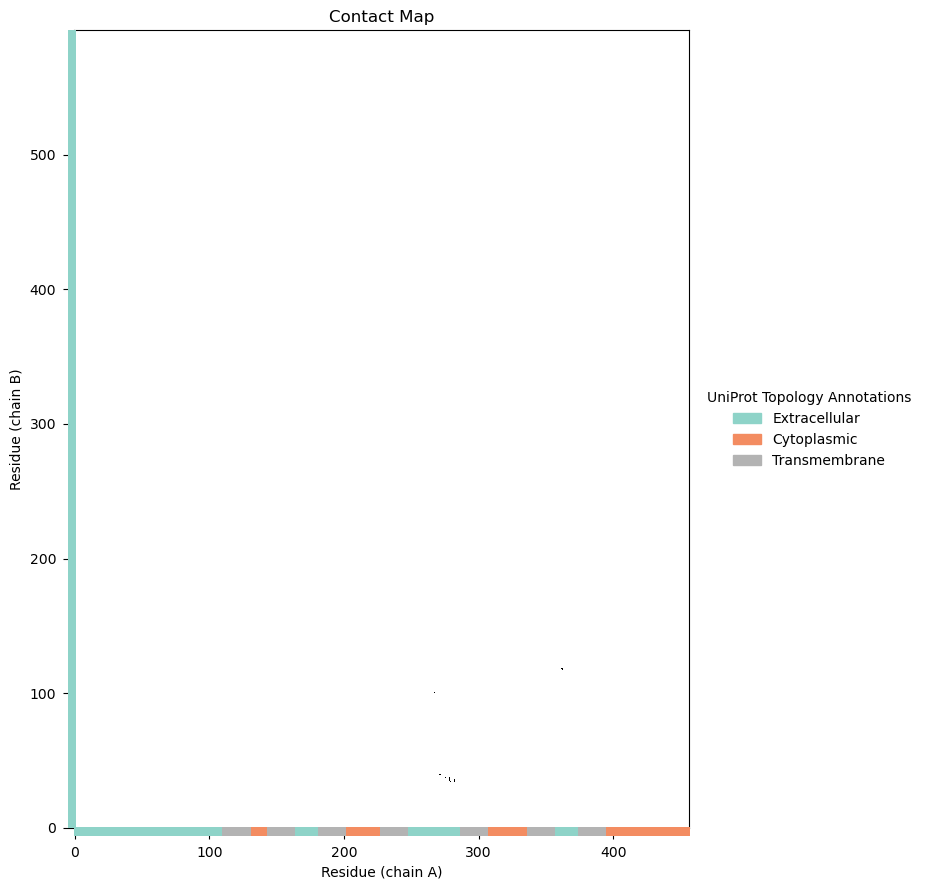

In [25]:
# plotting the contact map
fig, ax = plt.subplots(figsize=(9, 9))

# main contact map
ax.imshow(contacts, cmap="binary", origin="lower", interpolation="nearest")
ax.set_aspect("equal")
ax.set_xlabel(f"Residue (chain {protein_a_id})")
ax.set_ylabel(f"Residue (chain {protein_b_id})")
ax.set_title("Contact Map")

from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# left topology annotation bar
ax_left = inset_axes(
    ax, width="4%", height="100%",
    bbox_to_anchor=(-0.01, 0, 0.30, 1),   # small negative so it sits inside
    bbox_transform=ax.transAxes, loc="lower left", borderpad=0
)
ax_left.imshow(row_codes[:, np.newaxis], cmap=cmap_topo, norm=norm_topo,
               origin="lower", aspect="auto", interpolation="nearest")
ax_left.axis("off")

# botton topology annotation bar
ax_bot = inset_axes(
    ax, width="100%", height="4%",
    bbox_to_anchor=(0, -0.01, 1, 0.30),   # just inside bottom
    bbox_transform=ax.transAxes, loc="lower left", borderpad=0
)
ax_bot.imshow(col_codes[np.newaxis, :], cmap=cmap_topo, norm=norm_topo,
              aspect="auto", interpolation="nearest")
ax_bot.axis("off")

# ticks params
ax.tick_params(axis="x", which="both", length=8, pad=5)
ax.tick_params(axis="y", which="both", length=8, pad=5)

# legend
handles = [Patch(color=color_map[k], label=k)
           for k in ["Extracellular", "Cytoplasmic", "Transmembrane"]]
ax.legend(handles=handles,
          title = "UniProt Topology Annotations",
          loc="center left",          
          bbox_to_anchor=(1.02, 0.5), 
          borderaxespad=0,
          frameon=False)

plt.tight_layout()
plt.show()

/var/folders/q5/pgtbl_8x25ngl_1yyvg49y280000gn/T/ipykernel_23956/180316611.py:83: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


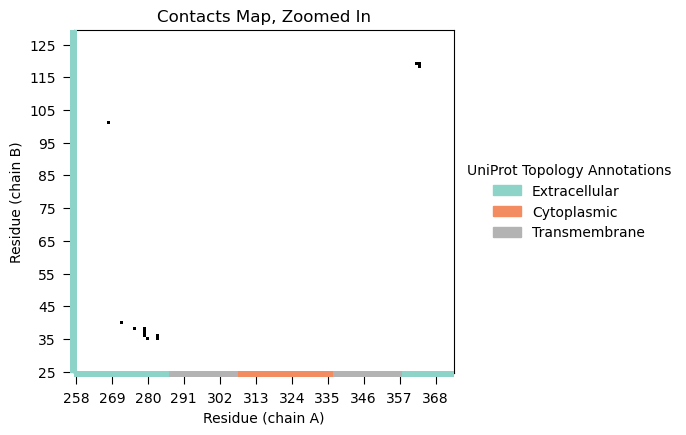

In [26]:
# Zoom in on the contacts map plot

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.patches import Patch

def plot_contacts_zoom(contacts, A, B, col_codes, row_codes,
                       protein_a_id="A", protein_b_id="B",
                       pad=10,
                       cmap_topo=None, norm_topo=None, color_map=None):
    """
    contacts: (NB x NA) bool, rows=B residues, cols=A residues
    A, B: AtomArray selections already sorted by res_id
    col_codes: int codes for chain A (len = NA)
    row_codes: int codes for chain B (len = NB)
    pad: residues padding around the tight contact box
    """
    ys, xs = np.where(contacts)
    if ys.size == 0:
        raise ValueError("No contacts found under the current threshold.")

    y0, y1 = ys.min(), ys.max()
    x0, x1 = xs.min(), xs.max()
    y0 = max(0, y0 - pad); y1 = min(contacts.shape[0] - 1, y1 + pad)
    x0 = max(0, x0 - pad); x1 = min(contacts.shape[1] - 1, x1 + pad)

    C = contacts[y0:y1+1, x0:x1+1]
    row_codes_z = row_codes[y0:y1+1]
    col_codes_z = col_codes[x0:x1+1]
    resA = A.res_id[x0:x1+1]   
    resB = B.res_id[y0:y1+1]   

    # plot
    fig, ax = plt.subplots(figsize=(7, 7))
    ax.imshow(C, cmap="binary", origin="lower", interpolation="nearest")
    ax.set_aspect("equal")
    ax.set_xlabel(f"Residue (chain {protein_a_id})")
    ax.set_ylabel(f"Residue (chain {protein_b_id})")
    ax.set_title(f"Contacts Map, Zoomed In")

    # put ticks every ~10 residues
    def sparse_ticks(n, step=10):
        idx = np.arange(0, n, step)
        return idx
    xt = sparse_ticks(C.shape[1], step=max(1, (x1-x0+1)//10))
    yt = sparse_ticks(C.shape[0], step=max(1, (y1-y0+1)//10))
    ax.set_xticks(xt); ax.set_xticklabels(resA[xt])
    ax.set_yticks(yt); ax.set_yticklabels(resB[yt])

    # topology annotation bars
    ax_left = inset_axes(ax, width="8%", height="100%",
                         bbox_to_anchor=(-0.01, 0, 0.20, 1),
                         bbox_transform=ax.transAxes, loc="lower left", borderpad=0)
    ax_left.imshow(row_codes_z[:, np.newaxis], cmap=cmap_topo, norm=norm_topo,
                   origin="lower", aspect="auto", interpolation="nearest")
    ax_left.axis("off")

    ax_bot = inset_axes(ax, width="100%", height="8%",
                        bbox_to_anchor=(0, -0.01, 1, 0.20),
                        bbox_transform=ax.transAxes, loc="lower left", borderpad=0)
    ax_bot.imshow(col_codes_z[np.newaxis, :], cmap=cmap_topo, norm=norm_topo,
                  aspect="auto", interpolation="nearest")
    ax_bot.axis("off")

    # ticks params
    ax.tick_params(axis="x", which="both", length=8, pad=5)
    ax.tick_params(axis="y", which="both", length=8, pad=5)

    # legend
    if color_map is not None:
        handles = [Patch(color=color_map[k], label=k)
                   for k in ["Extracellular", "Cytoplasmic", "Transmembrane"] if k in color_map]
        ax.legend(
        handles=handles,
          loc="center left",          
          title = "UniProt Topology Annotations",
          bbox_to_anchor=(1.02, 0.5),
          borderaxespad=0,
          frameon=False
        )

    plt.tight_layout()
    plt.show()


plot_contacts_zoom(
    contacts=contacts,
    A=A, B=B,
    col_codes=col_codes, row_codes=row_codes,
    protein_a_id=protein_a_id, protein_b_id=protein_b_id,
    pad=10,
    cmap_topo=cmap_topo, norm_topo=norm_topo, color_map=color_map
)